In [1]:
# 4 Final Project Idea: Analyzing Data
# 4.2 Importing Data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("exoplanet_data.csv", comment = "#")

print(df.shape)
# It has 567 rows and 92 columns

print(df.columns)
# I don't know what almost any of them mean. Like sy_snum, sy_pnum, pl_insol, pl_eqte, or st_tef.

(567, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [2]:
# 4.3 Reducing Data
# Planet name: pl_name, the most commonly used name of the planet
# Host name: hostname, the most commonly used name of the star
# Discovery method: discoverymethod, method used to first identify the planet
# Spectral type: st_spectype, the Morgan-Keenan system's classification of the star
# Equilibrium temperature [K]: pl_eqt, the equilibrium temperature of the planet in Kelvin
# Planet mass or mass*sin(i) [Jupiter Mass], pl_bmassj, the best approximation of mass available for the exoplanet, measured in jupiter masses.

df2 = df[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]

df2 = df2.dropna()

print(df2.shape)
# the new dataframe has 67 rows and 6 columns
print(df2.head(5))
print(df2.tail(5))
print(df2.columns)


(67, 6)
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
546   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
549   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
555   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
561       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [3]:
# 4.4 Analyze Data
# 4.4.1
print(df2["discoverymethod"].value_counts())
# The different methods are transit, radial veocity, and imaging. Transit has the most while radial velocity has the least.
# The transit method is used to detect when an exoplanet crosses in front of a star, which dims the light we receive slightly, and shows that there is an exoplanet there.
# The radial velocity method is where we detect a variation in the doppler shifting of light coming from a star, which results from an exoplanet gravitationally causing a star to wobble a lil bit.
# The imaging method is where we take a direct image of an exoplanet by blocking out the light from the star it orbits.

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


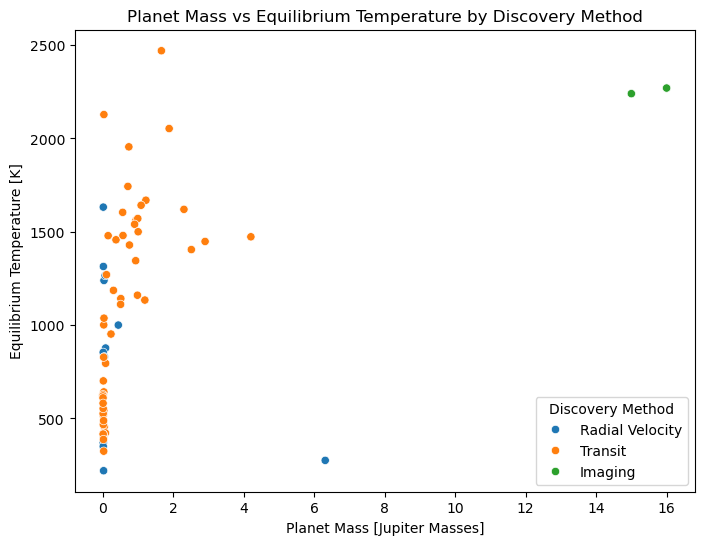

In [4]:
# 4.4.2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2, x="pl_bmassj", y="pl_eqt", hue="discoverymethod")
plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method")
plt.xlabel("Planet Mass [Jupiter Masses]")
plt.ylabel("Equilibrium Temperature [K]")
plt.legend(title="Discovery Method")
plt.show()

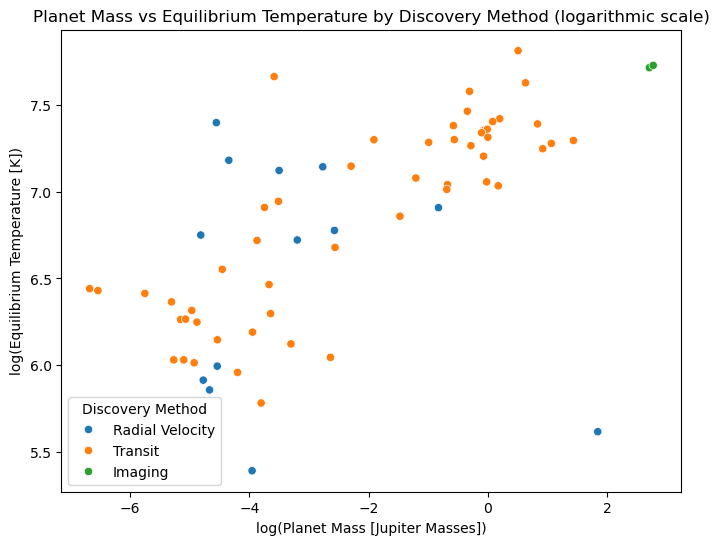

In [5]:
# 4.4.3
df2["log_mass"] = np.log(df2["pl_bmassj"])
df2["log_temp"] = np.log(df2["pl_eqt"])

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df2, x="log_mass", y="log_temp", hue="discoverymethod")

plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method (logarithmic scale)")
plt.xlabel("log(Planet Mass [Jupiter Masses])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend(title="Discovery Method")
plt.show()

In [6]:
# 4.4.4
# Exoplanets found using the imaging method are more likely to be massive.

In [7]:
# 4.4.5
massive = df2[df2["pl_bmassj"] > 5]
print(massive)
# The coldest planet with this mass is eps Ind A b

         pl_name    hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj  \
481   USco1556 b  USco1556 A          Imaging      M3.0 V  2240.0      15.00   
482   USco1621 b  USco1621 A          Imaging      M2.5 V  2270.0      16.00   
566  eps Ind A b   eps Ind A  Radial Velocity        K5 V   275.0       6.31   

     log_mass  log_temp  
481  2.708050  7.714231  
482  2.772589  7.727535  
566  1.842136  5.616771  


In [8]:
# 4.4.6
coldest=(df2.loc[566])
print(coldest)
# The planet is named eps Ind A b.
# It is at index 566
# Its equilibrium temperature is 275 K
# Its mass is 6.31 Jupiter masses
# It is orbiting a K type star, meaning it is relatively similar to the sun, but a little colder and less massive.

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
log_mass                  1.842136
log_temp                  5.616771
Name: 566, dtype: object


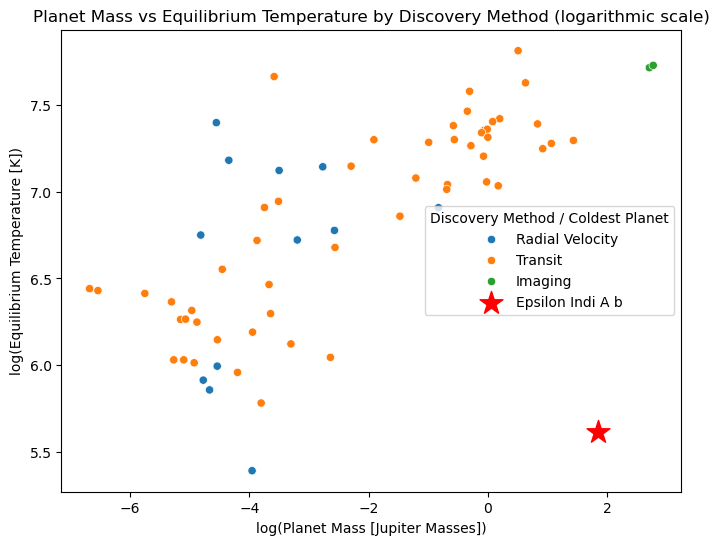

In [9]:
# 4.4.7
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df2, x="log_mass", y="log_temp", hue="discoverymethod")

plt.scatter(coldest["log_mass"], coldest["log_temp"], color = "red", marker="*", s=300, label = "Epsilon Indi A b")

plt.title("Planet Mass vs Equilibrium Temperature by Discovery Method (logarithmic scale)")
plt.xlabel("log(Planet Mass [Jupiter Masses])")
plt.ylabel("log(Equilibrium Temperature [K])")
plt.legend(title="Discovery Method / Coldest Planet")
plt.show()

In [10]:
# 4.5 Check Your Answer
# The title is: A temperate super-Jupiter imaged with JWST in the mid-infrared
# The abstract explains how previousy astronomers had detected a planet around Eps Ind A using the radial velocity method, and recently an exoplanet was detected with the JWST using direct imaging. The measurements from the direct imaging of the exoplanet share some properties with what the exoplanet was previously believed to have, but there are also differences in their properties.
# My answer does match this exoplanet
# The planet I found was both particulary massive and particularly cold compared to all the other exoplanets.
# The equilibrium temperature in the data of 275 K does match the paper, which reports a temperature of 300 K or 275 K depending on different models. Additionally, the paper reports that the planet has 6.31 jupiter masses, which is the same as the planet I found in the data.